In [4]:
# these can be turned on for development work
%load_ext autoreload
%autoreload 2

In [5]:
# setting up logging first or else it gets preempted by another package
import watershed_workflow.ui
watershed_workflow.ui.setup_logging(1)

In [6]:
import os,sys
import logging
import numpy as np
from matplotlib import pyplot as plt
import shapely
import pandas as pd
import geopandas as gpd
pd.options.display.max_columns = None
import pickle

import watershed_workflow 
import watershed_workflow.config
import watershed_workflow.sources
import watershed_workflow.sources.standard_names as names

# set the default figure size for notebooks
plt.rcParams["figure.figsize"] = (8, 6)

## Input: Parameters and other source data

In [7]:
# Force Watershed Workflow to pull data from this directory rather than a shared data directory.
# This picks up the Coweeta-specific datasets set up here to avoid large file downloads for 
# demonstration purposes.
#
def splitPathFull(path):
    """
    Splits an absolute path into a list of components such that
    os.path.join(*splitPathFull(path)) == path
    """
    parts = []
    while True:
        head, tail = os.path.split(path)
        if head == path:  # root on Unix or drive letter with backslash on Windows (e.g., C:\)
            parts.insert(0, head)
            break
        elif tail == path:  # just a single file or directory
            parts.insert(0, tail)
            break
        else:
            parts.insert(0, tail)
            path = head
    return parts

cwd = splitPathFull(os.getcwd())
assert cwd[-1] == 'Neches_new'
cwd = cwd[:-1]

# Note, this directory is where downloaded data will be put as well
data_dir = os.path.join(*(cwd + ['input_data',]))
def toInput(filename):
    return os.path.join(data_dir, filename)

output_dir = os.path.join(*(cwd + ['output_data',]))
output_filenames = dict()
def fromOutput(filename):
    return os.path.join(output_dir, filename)    

def toOutput(role, filename):
    output_filenames[role] = filename
    return fromOutput(filename)

# check output and input dirs exist
if not os.path.isdir(data_dir):
    os.makedirs(data_dir, exist_ok=True)
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)
       

In [8]:
# Set the data directory to the local space to get the locally downloaded files
watershed_workflow.config.setDataDirectory(data_dir)


In [9]:
## Parameters cell -- this provides all parameters that can be changed via pipelining to generate a new watershed. 
name = 'Neches_River'
hucs = ['1202'] # a list of HUCs to run


# Geometric parameters
# -- parameters to clean and reduce the river network prior to meshing
prune_by_area = 10               # km^2
simplify = 125                   # length scale to target average edge 

# -- mesh triangle refinement control
refine_d0 = 200
refine_d1 = 600

refine_L0 = 125
refine_L1 = 300

refine_A0 = refine_L0**2 / 2
refine_A1 = refine_L1**2 / 2

# Note that, by default, we tend to work in the DayMet CRS because this allows us to avoid
# reprojecting meteorological forcing datasets.
crs = watershed_workflow.crs.default_crs


In [10]:
# set up a dictionary of source objects
#
# Data sources, also called managers, deal with downloading and parsing data files from a variety of online APIs.
sources = watershed_workflow.sources.getDefaultSources()

# log the sources that will be used here
watershed_workflow.sources.logSources(sources)



2025-11-21 12:48:40,125 - root - INFO: Using sources:
2025-11-21 12:48:40,131 - root - INFO: --------------
2025-11-21 12:48:40,134 - root - INFO: HUC: WBD
2025-11-21 12:48:40,136 - root - INFO: hydrography: NHDPlus MR v2.1
2025-11-21 12:48:40,136 - root - INFO: DEM: 3DEP 60m
2025-11-21 12:48:40,137 - root - INFO: soil structure: National Resources Conservation Service Soil Survey (NRCS Soils)
2025-11-21 12:48:40,138 - root - INFO: geologic structure: shapefile: "GLHYMPS.shp"
2025-11-21 12:48:40,138 - root - INFO: land cover: NLCD 2021 L48
2025-11-21 12:48:40,139 - root - INFO: LAI: MODIS
2025-11-21 12:48:40,139 - root - INFO: depth to bedrock: raster: "average_soil_and_sedimentary-deposit_thickness.tif"
2025-11-21 12:48:40,139 - root - INFO: meteorology: AORC v1.1


In [11]:
# get the shape and crs of the shape
print(crs)
watershed_shapes = sources['HUC'].getShapesByID(hucs, out_crs=crs)
print(watershed_shapes.crs)

EPSG:5070


2025-11-21 12:48:40,583 - root - INFO: fixing column: geometry


EPSG:5070


## the Watershed

2025-11-21 12:48:40,957 - root - INFO: Removing holes on 1 polygons
2025-11-21 12:48:40,959 - root - INFO:   -- removed interior
2025-11-21 12:48:40,961 - root - INFO:   -- union
2025-11-21 12:48:40,961 - root - INFO: Parsing 1 components for holes
2025-11-21 12:48:40,962 - root - INFO:   -- complete


<Axes: >

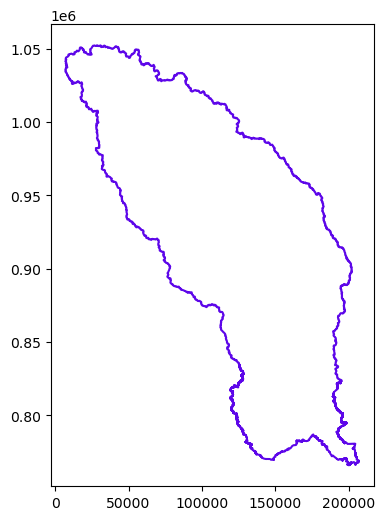

In [12]:
# Construct and plot the WW object used for storing watersheds
watershed = watershed_workflow.split_hucs.SplitHUCs(watershed_shapes)
watershed.plot()

## Gage Data

In [23]:
watershed.df

,geometry,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc4,name,globalid,shape_Length,shape_Area,ID,area,huc
0,"POLYGON ((28901.959 1051954.48, 28746.235 1052...",25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202


In [25]:
type(watershed_shapes)

geopandas.geodataframe.GeoDataFrame

In [14]:
# find all gages in the river
import pygeohydro

# Initialize NWIS
nwis = pygeohydro.NWIS()
bbox = ','.join(f"{b:.06f}" for b in watershed_shapes.to_crs(watershed_workflow.crs.latlon_crs).geometry[0].bounds)
print(bbox)

query = {
    "bBox": bbox,
    "siteType": "ST",  # stream types
    "parameterCd": "00060,00065", # Discharge and Gage height
    "hasDataTypeCd": "dv",  # Daily values
    "outputDataTypeCd": "dv",  # Output as daily values
}

#
# Fetch all available gages within the bounding box
sites = nwis.get_info(query).to_crs(crs)

#
# Spatial join: keep only sites that fall inside the watershed, not the bounds
sites = gpd.sjoin(sites, watershed_shapes, how="inner", predicate="intersects")

#
# limit to sites with end_date after 2000 -- they MIGHT have good data
sites = sites[sites['end_date'] > '2000-01-01']

sites

-95.925807,29.949993,-93.853411,32.542338


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,alt_va,alt_acy_va,alt_datum_cd,huc_cd,data_type_cd,parm_cd,stat_cd,ts_id,loc_web_ds,medium_grp_cd,parm_grp_cd,srs_id,access_cd,begin_date,end_date,count_nu,hcdn_2009,geometry,index_right,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc4,name,globalid,shape_Length,shape_Area,ID,area,huc
75,USGS,08032000,"Neches Rv Nr Neches, TX",ST,31.892390,-95.430786,F,NAD83,262.74,0.25,NAVD88,12020001,dv,00060,00003,132770,,wat,,1645423,0,1939-02-09,2025-11-17,26580,False,POINT (53602.148 979953.881),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202
76,USGS,08032000,"Neches Rv Nr Neches, TX",ST,31.892390,-95.430786,F,NAD83,262.74,0.25,NAVD88,12020001,dv,00065,00003,132771,,wat,,17164583,0,1998-10-01,2025-11-17,9766,False,POINT (53602.148 979953.881),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202
78,USGS,08032700,"Neches Rv At Sh 7 Nr Pollok, TX",ST,31.396706,-94.965800,5,NAD83,0.00,0.20,NAVD88,12020002,dv,00060,00003,285331,,wat,,1645423,0,2019-07-25,2025-11-17,2308,False,POINT (97988.231 925133.991),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202
79,USGS,08032700,"Neches Rv At Sh 7 Nr Pollok, TX",ST,31.396706,-94.965800,5,NAD83,0.00,0.20,NAVD88,12020002,dv,00065,00003,325628,[Primary Sensor],wat,,17164583,0,2019-07-25,2025-11-18,2309,False,POINT (97988.231 925133.991),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202
80,USGS,08033000,"Neches Rv Nr Diboll, TX",ST,31.132968,-94.809946,F,NAD83,133.93,0.24,NAVD88,12020002,dv,00060,00001,164769,,wat,,1645423,0,1987-07-08,2025-11-17,7082,False,POINT (113121.759 895964.13),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202
81,USGS,08033000,"Neches Rv Nr Diboll, TX",ST,31.132968,-94.809946,F,NAD83,133.93,0.24,NAVD88,12020002,dv,00060,00002,164770,,wat,,1645423,0,2000-05-10,2025-11-17,4372,False,POINT (113121.759 895964.13),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202
82,USGS,08033000,"Neches Rv Nr Diboll, TX",ST,31.132968,-94.809946,F,NAD83,133.93,0.24,NAVD88,12020002,dv,00060,00003,132779,,wat,,1645423,0,1923-10-01,2025-11-17,21783,False,POINT (113121.759 895964.13),0,25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,2590

In [15]:
#
# do they actually have data?  download discharge
#
dates = ('2000-01-01', '2026-01-01')
qobs = nwis.get_streamflow(sites.site_no.to_list(), dates, mmd=True)
qobs

,USGS-08032000,USGS-08032700,USGS-08033000,USGS-08033500,USGS-08033900,USGS-08034500,USGS-08036500,USGS-08037050,USGS-08037180,USGS-08040600,USGS-08041000,USGS-08041300,USGS-08041500,USGS-08041700,USGS-08041749,USGS-08041780
2000-01-01 06:00:00+00:00,NaN,NaN,NaN,0.065021,NaN,NaN,0.099433,NaN,NaN,NaN,0.341699,NaN,0.214859,0.009423,NaN,NaN
2000-01-02 06:00:00+00:00,NaN,NaN,NaN,0.064241,NaN,NaN,0.099433,NaN,NaN,NaN,0.341699,NaN,0.210474,0.010459,NaN,NaN
2000-01-03 06:00:00+00:00,NaN,NaN,NaN,0.063201,NaN,NaN,0.100917,NaN,NaN,NaN,0.342898,NaN,0.210474,0.012869,NaN,NaN
2000-01-04 06:00:00+00:00,NaN,NaN,NaN,0.061120,NaN,NaN,0.100175,NaN,NaN,NaN,0.342898,NaN,0.207186,0.013712,NaN,NaN
2000-01-05 06:00:00+00:00,NaN,NaN,NaN,0.061120,NaN,NaN,0.097949,NaN,NaN,NaN,0.339301,NaN,0.203897,0.012700,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-13 06:00:00+00:00,0.092489,0.082685,0.071857,0.065541,0.116464,0.095127,0.074056,0.131564,0.074778,0.208314,0.175046,0.138684,0.088465,0.004675,NaN,0.114020
2025-11-14 06:00:00+00:00,0.091671,0.086903,0.070815,0.064501,0.123631,0.101151,0.070791,0.134874,0.072423,0.198335,0.176245,0.137297,0.085396,0.004988,NaN,0.114978
2025-11-15 06:00:00+00:00,0.094126,0.094918,0.069427,0.062940,0.123034,0.105669,0.069529,0.133219,0.072423,0.145944,0.173847,0.139030,0.083861,0.004699,NaN,0.118811
2025-11-16 06:00:00+00:00,0.094126,0.094075,0.071857,0.061120,0.126617,0.102908,0.069232,0.127703,0.072423,0.142202,0.143873,0.140764,0.084299,0.004434,NaN,0.120727


In [16]:
#
# 36 have data... how many have lots of data?  Lets say at least 10 years of daily data since 2000...
#
qobs_10yrs_k = [k for k in qobs.keys() if qobs[k].count() > 1*365]
len(qobs_10yrs_k)

# these are the 24 that we will mesh into the domain...
qobs_10yrs = qobs[qobs_10yrs_k]
qobs_10yrs

,USGS-08032000,USGS-08032700,USGS-08033000,USGS-08033500,USGS-08033900,USGS-08034500,USGS-08036500,USGS-08037050,USGS-08037180,USGS-08040600,USGS-08041000,USGS-08041300,USGS-08041500,USGS-08041700,USGS-08041780
2000-01-01 06:00:00+00:00,NaN,NaN,NaN,0.065021,NaN,NaN,0.099433,NaN,NaN,NaN,0.341699,NaN,0.214859,0.009423,NaN
2000-01-02 06:00:00+00:00,NaN,NaN,NaN,0.064241,NaN,NaN,0.099433,NaN,NaN,NaN,0.341699,NaN,0.210474,0.010459,NaN
2000-01-03 06:00:00+00:00,NaN,NaN,NaN,0.063201,NaN,NaN,0.100917,NaN,NaN,NaN,0.342898,NaN,0.210474,0.012869,NaN
2000-01-04 06:00:00+00:00,NaN,NaN,NaN,0.061120,NaN,NaN,0.100175,NaN,NaN,NaN,0.342898,NaN,0.207186,0.013712,NaN
2000-01-05 06:00:00+00:00,NaN,NaN,NaN,0.061120,NaN,NaN,0.097949,NaN,NaN,NaN,0.339301,NaN,0.203897,0.012700,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-13 06:00:00+00:00,0.092489,0.082685,0.071857,0.065541,0.116464,0.095127,0.074056,0.131564,0.074778,0.208314,0.175046,0.138684,0.088465,0.004675,0.114020
2025-11-14 06:00:00+00:00,0.091671,0.086903,0.070815,0.064501,0.123631,0.101151,0.070791,0.134874,0.072423,0.198335,0.176245,0.137297,0.085396,0.004988,0.114978
2025-11-15 06:00:00+00:00,0.094126,0.094918,0.069427,0.062940,0.123034,0.105669,0.069529,0.133219,0.072423,0.145944,0.173847,0.139030,0.083861,0.004699,0.118811
2025-11-16 06:00:00+00:00,0.094126,0.094075,0.071857,0.061120,0.126617,0.102908,0.069232,0.127703,0.072423,0.142202,0.143873,0.140764,0.084299,0.004434,0.120727


In [17]:
#
# create a new sites dataframe, that just has the metadata of continuous sites, and not repeated site_nos associated with different ranges
#
geom = [shapely.geometry.Point(qobs_10yrs.attrs[k]['dec_long_va'], qobs_10yrs.attrs[k]['dec_lat_va']) for k in qobs_10yrs.keys()] 
sites_10yrs = gpd.GeoDataFrame(geometry=geom, crs=watershed_workflow.crs.latlon_crs)

cols = qobs_10yrs.attrs[list(qobs_10yrs.keys())[0]].keys()
for col in cols:
    vals = [qobs_10yrs.attrs[k][col] for k in qobs_10yrs.keys()]
    sites_10yrs[col] = vals    

sites_10yrs['ID'] = list(qobs_10yrs.keys())
sites_10yrs['count'] = [qobs_10yrs[k].count() for k in qobs_10yrs.keys()]
sites_10yrs = sites_10yrs.to_crs(crs)
sites_10yrs

,geometry,station_nm,dec_lat_va,dec_long_va,alt_va,alt_acy_va,alt_datum_cd,huc_cd,begin_date,end_date,units,tz,ID,count
0,POINT (53601.768 979953.578),"Neches Rv Nr Neches, TX",31.892390,-95.430786,262.74,0.25,NAVD88,12020001,1939-02-09,2025-11-20,mm/day,UTC,USGS-08032000,8815
1,POINT (97987.872 925133.649),"Neches Rv At Sh 7 Nr Pollok, TX",31.396706,-94.965800,0.00,0.20,NAVD88,12020002,2019-07-25,2025-11-20,mm/day,UTC,USGS-08032700,2308
2,POINT (113121.43 895963.777),"Neches Rv Nr Diboll, TX",31.132968,-94.809946,133.93,0.24,NAVD88,12020002,1923-10-01,2025-11-20,mm/day,UTC,USGS-08033000,4067
3,POINT (152340.927 884529.592),"Neches Rv Nr Rockland, TX",31.025000,-94.399444,88.41,0.10,NGVD29,12020003,1903-07-01,2025-11-20,mm/day,UTC,USGS-08033500,9453
4,POINT (110852.658 976890.41),"E Fk Angelina Rv Nr Cushing, TX",31.860172,-94.823270,291.06,0.10,NAVD88,12020004,1964-01-01,2025-11-20,mm/day,UTC,USGS-08033900,3701
5,POINT (78944.472 989518.091),"Mud Ck Nr Jacksonville, TX",31.976556,-95.160779,271.63,0.25,NAVD88,12020004,1939-05-06,2025-11-20,mm/day,UTC,USGS-08034500,8888
6,POINT (98890.04 955774.66),"Angelina Rv Nr Alto, TX",31.671844,-94.952715,214.30,0.10,NGVD29,12020004,1940-10-01,2025-11-20,mm/day,UTC,USGS-08036500,9451
7,POINT (128351.737 950116.097),"Bayou Lanana At Nacogdoches, TX",31.617679,-94.641598,264.23,0.10,NGVD29,12020005,1964-10-01,2025-11-20,mm/day,UTC,USGS-08037050,3173
8,POINT (120585.823 932139.771),"Angelina Rv At Hwy 59 Nr Lufkin, TX",31.457183,-94.726328,0.00,0.10,NAVD88,12020004,2020-01-16,2025-11-20,mm/day,UTC,USGS-08037180,2133
9,POINT (176488.928 858949.868),"Neches Rv Nr Town Bluff, TX",30.791036,-94.151024,0.00,1.00,NGVD29,12020003,1951-04-01,2025-11-20,mm/day,UTC,USGS-08040600,9180


In [18]:
import pynhd
nldi = pynhd.NLDI()

features = nldi.getfeature_byid("nwissite", sites_10yrs['ID'])

# pull a few things over from the nwis data
sites_10yrs['comid'] = features['comid'].astype(int)
sites_10yrs['measure'] = features['measure'] # in % of total length, the distance up the reach from the downstream point to the gage
sites_10yrs

,geometry,station_nm,dec_lat_va,dec_long_va,alt_va,alt_acy_va,alt_datum_cd,huc_cd,begin_date,end_date,units,tz,ID,count,comid,measure
0,POINT (53601.768 979953.578),"Neches Rv Nr Neches, TX",31.892390,-95.430786,262.74,0.25,NAVD88,12020001,1939-02-09,2025-11-20,mm/day,UTC,USGS-08032000,8815,4452936,88.2990
1,POINT (97987.872 925133.649),"Neches Rv At Sh 7 Nr Pollok, TX",31.396706,-94.965800,0.00,0.20,NAVD88,12020002,2019-07-25,2025-11-20,mm/day,UTC,USGS-08032700,2308,1078299,31.2719
2,POINT (113121.43 895963.777),"Neches Rv Nr Diboll, TX",31.132968,-94.809946,133.93,0.24,NAVD88,12020002,1923-10-01,2025-11-20,mm/day,UTC,USGS-08033000,4067,1079041,14.9430
3,POINT (152340.927 884529.592),"Neches Rv Nr Rockland, TX",31.025000,-94.399444,88.41,0.10,NGVD29,12020003,1903-07-01,2025-11-20,mm/day,UTC,USGS-08033500,9453,1109655,68.3590
4,POINT (110852.658 976890.41),"E Fk Angelina Rv Nr Cushing, TX",31.860172,-94.823270,291.06,0.10,NAVD88,12020004,1964-01-01,2025-11-20,mm/day,UTC,USGS-08033900,3701,1149925,94.6010
5,POINT (78944.472 989518.091),"Mud Ck Nr Jacksonville, TX",31.976556,-95.160779,271.63,0.25,NAVD88,12020004,1939-05-06,2025-11-20,mm/day,UTC,USGS-08034500,8888,1151409,32.9100
6,POINT (98890.04 955774.66),"Angelina Rv Nr Alto, TX",31.671844,-94.952715,214.30,0.10,NGVD29,12020004,1940-10-01,2025-11-20,mm/day,UTC,USGS-08036500,9451,1150499,25.7910
7,POINT (128351.737 950116.097),"Bayou Lanana At Nacogdoches, TX",31.617679,-94.641598,264.23,0.10,NGVD29,12020005,1964-10-01,2025-11-20,mm/day,UTC,USGS-08037050,3173,1158005,44.6921
8,POINT (120585.823 932139.771),"Angelina Rv At Hwy 59 Nr Lufkin, TX",31.457183,-94.726328,0.00,0.10,NAVD88,12020004,2020-01-16,2025-11-20,mm/day,UTC,USGS-08037180,2133,1152351,6.7015
9,POINT (176488.928 858949.868),"Neches Rv Nr Town Bluff, TX",30.791036,-94.151024,0.00,1.00,NGVD29,12020003,1951-04-01,2025-11-20,mm/day,UTC,USGS-08040600,9180,1111453,36.6780


In [19]:
# check that no two gages are on the same reach -- this would break our subdomain decomposition
assert len(set(sites_10yrs.comid.tolist())) == len(sites_10yrs)

In [20]:
# check if there are pairs of points that are super close

def checkTooClose(pts, geom='geometry'):
    pairs_dist = []
    pairs_comid = []
    threshold = 1000 # m
    
    for i, geom1 in enumerate(pts[geom]):
        for j, geom2 in enumerate(pts[geom]):
            if i < j:
                d = geom1.distance(geom2)
                if d <= threshold:
                    pairs_dist.append((pts.index[i], pts.index[j], d))
    
                if pts.iloc[i].comid == pts.iloc[j].comid:
                    pairs_comid.append((pts.index[i], pts.index[j], pts.iloc[j].comid))
    
    print('Close pairs:')
    for i,j,d in pairs_dist:
        print(f'point {i} ({pts.loc[i, geom]}) and point {j} {pts.loc[j,geom]}) are within {d} m')
    
    print('Shared comid:')
    for i,j,c in pairs_comid:
        print(f'point {i} ({pts.loc[i, geom]}) and point {j} {pts.loc[j,geom]}) share comid {c}')
    return pairs_dist, pairs_comid

pairs_dist, _ = checkTooClose(sites_10yrs)

Close pairs:
Shared comid:


In [21]:
watershed.df

,geometry,objectid,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc4,name,globalid,shape_Length,shape_Area,ID,area,huc
0,"POLYGON ((28901.959 1051954.48, 28746.235 1052...",25,{75FA67DA-090D-4901-80E0-163036B25DA1},{2F42D1FB-7624-4C17-A5F6-ECFEE2271019},Watershed Boundary Dataset (WBD),Natural Resources and Conservation Service and...,None,1727788855000,1363629,6400335.32,25901.26,TX,1202,Neches,{65C9A274-2961-4ADF-B24C-A3EB96D642AA},1.563153e+06,3.562257e+10,1202,25901.26,1202


## the Rivers 

In [22]:
# download/collect the river network within that shape's bounds
reaches = sources['hydrography'].getShapesByGeometry(watershed.df, out_crs=crs)

# remove coastlines
reaches = reaches[reaches.ftype != 'Coastline']
print(reaches.crs)

# construct rivers
rivers = watershed_workflow.river_tree.createRivers(reaches, method='hydroseq')
print(rivers[0].df.crs)

reaches

ServiceError: Service returned the following error message:
URL: https://api.water.usgs.gov/geoserver/wmadata/ows
ERROR: <?xml version="1.0" encoding="UTF-8"?><ows:ExceptionReport xmlns:xs="http://www.w3.org/2001/XMLSchema" xmlns:ows="http://www.opengis.net/ows" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" version="1.0.0" xsi:schemaLocation="http://www.opengis.net/ows https://api.water.usgs.gov/geoserver/schemas/ows/1.0.0/owsExceptionReport.xsd">
  <ows:Exception exceptionCode="InvalidParameterValue" locator="service">
    <ows:ExceptionText>No service: ( ows )</ows:ExceptionText>
  </ows:Exception>
</ows:ExceptionReport>



In [ ]:
#
# are all of our gage-reaches in the set of reaches?
print(sum(sites_10yrs['comid'].isin(reaches['comid'])), ' of ', len(sites_10yrs), ' are in the set of ALL reaches')

In [ ]:
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ws.plot(color='k', marker='+', markersize=10, ax=ax)
    for river in rivs:
        river.plot(marker='x', markersize=10, ax=ax)

    return ax

ax = plot(watershed, rivers)

In [ ]:
def plot(ws, rivs, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,10))
    
    # plot watershed
    ws.plot(color='k', markersize=5, ax=ax)
    
    # color palette
    colors = plt.cm.tab20.colors
    
    # plot rivers with unique colors
    for i, river in enumerate(rivs):
        river.plot(markersize=1, ax=ax, color=colors[i % 20],label=f"River {i}")
    
    ax.legend()
    return ax

ax = plot(watershed, rivers)
plt.show()

In [ ]:
print(len(rivers))

In [ ]:
for i, r in enumerate(rivers):
    print(f"River {i}: {r['name']}, reaches = {len(r.df)}")

In [ ]:
rivers = [r for r in rivers if len(r.df) >= 101]

In [ ]:
for i, r in enumerate(rivers):
    print(f"River {i}: {r['name']}, reaches = {len(r.df)}")

In [ ]:
# prune

pruned_r0 = watershed_workflow.reduceRivers([rivers[0]],
                                            prune_by_area=prune_by_area,
                                            remove_diversions=True,
                                            remove_braided_divergences=True)[0]

pruned_r0.resetDataFrame()
rivers[0] = pruned_r0

prune_by_area2=10

pruned_r1= watershed_workflow.reduceRivers([rivers[1]],
                                            prune_by_area=prune_by_area2,
                                            remove_diversions=True,
                                            remove_braided_divergences=True)[0]

pruned_r1.resetDataFrame()
rivers[1] = pruned_r1

reduced_reaches = pd.concat([r.df for r in rivers])

In [ ]:
for i, r in enumerate(rivers):
    print(f"River {i}: {r['name']}, reaches = {len(r.df)}")

In [ ]:
plot(watershed, rivers)

In [ ]:
shp_path = "/Users/s2t/research/neches/scripts/outlets_with_subbasins.shp"

# load it as a GeoDataFrame
outlets = gpd.read_file(shp_path)

In [ ]:
outlets = outlets.to_crs(watershed_workflow.crs.default_crs)
outlets

In [ ]:
outlets.loc[17, 'comid'] = 1524153

In [ ]:
watershed.df

In [ ]:
outlets

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
watershed.df.plot(ax=ax, facecolor='none', edgecolor='black')
rivers[0].plot(ax=ax)
rivers[1].plot(ax=ax, linestyle='-')
outlets.plot(ax=ax, color='red', markersize=50, edgecolor='black')

for x, y, label in zip(outlets.geometry.x, outlets.geometry.y,outlets['outlet_ID']):
    ax.text(x + 200, y + 200, label, fontsize=8)

plt.show()

In [ ]:
# are all of our gages STILL in our reduced network?
print(sum(outlets['comid'].isin(reduced_reaches['comid'])), ' of ', len(outlets), ' are in the set of REDUCED reaches')

In [ ]:
# river_df = gpd.GeoDataFrame(pd.concat([r.to_dataframe() for r in rivers]), crs=crs)
# river_df.to_parquet(toOutput('rivers', '01_rivers.parquet'))

In [ ]:
# # Convert geometry to WKT text
# river_df['geometry'] = river_df['geometry'].apply(lambda g: g.wkt if g is not None else None)

# # Save as CSV
# river_df.to_csv("/Users/s2t/research/neches/scripts/01_rivers.csv", index=False)


In [ ]:
watershed.df.columns


In [ ]:
# # this generates a zoomable map, showing different reaches and watersheds, 
# # with discrete points.  Problem areas are clickable to get IDs for manual
# # modifications.
# m = watershed.explore(marker=False)
# for river in rivers_orig:
#     m = river.explore(m=m, column=None, color='black', name=river['name']+' raw', marker=False)
# for river in rivers:
#     m = river.explore(m=m)
    
# m = watershed_workflow.makeMap(m)
# m

In [ ]:
print(rivers[1].df.columns)

In [ ]:

node_1 = rivers[1].df.index[rivers[1].df['reachcode'] == '12040202000305'].tolist()[0]


In [ ]:
node = rivers[1].getNode(node_1)  
geom = node['geometry']
gdf = gpd.GeoDataFrame({'geometry': [geom]})

gdf.plot()

In [ ]:
from shapely.geometry import LineString
coords = list(node['geometry'].coords)
coords[-1] = (145522.975, 715734.527)
node['geometry'] = LineString(coords)

# Plot
gpd.GeoDataFrame({'geometry':[node['geometry']]}).plot()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
watershed.df.plot(ax=ax, facecolor='none', edgecolor='black')
rivers[0].plot(ax=ax)
rivers[1].plot(ax=ax, linestyle='-')
outlets.plot(ax=ax, color='red', markersize=50, edgecolor='black')

for x, y, label in zip(outlets.geometry.x, outlets.geometry.y,outlets['outlet_ID']):
    ax.text(x + 200, y + 200, label, fontsize=8)

plt.show()

In [ ]:
# are all of our gages STILL in our reduced network?
print(sum(outlets['comid'].isin(reduced_reaches['comid'])), ' of ', len(outlets), ' are in the set of REDUCED reaches')

In [ ]:
rivers[0].isContinuous()

In [ ]:
rivers[0].makeContinuous()

In [ ]:
# simplifying 
watershed_workflow.simplify(watershed, rivers, 
                            reach_segment_target_length=100,
                            huc_segment_target_length=300,
                            river_close_distance=100,
                            river_far_distance=300,
                            snap_triple_junctions_tol=300)
                           

# greatly shrunk the rivers... shrink the dataframe too
for river in rivers:
    river.resetDataFrame()

In [ ]:
for river in rivers:
    river.resetDataFrame()

# Now that the river network is set, find the watershed boundary outlets
for river in rivers:
    watershed_workflow.hydrography.findOutletsByCrossings(watershed, river)

In [ ]:
print(len(watershed.df))  
